# Privacy & Governance Analysis — NovaCred Credit Applications

**Course:** Data Ecosystems and Governance in Organizations (DEGO 2606)
**Institution:** Nova School of Business and Economics — MSc Business Analytics
**Role:** Governance Officer

---

| Task | Description |
|---|---|
| PII Identification | Map all personally identifiable fields in the dataset |
| Privacy Risk Analysis | Assess governance risks from sensitive data storage |
| Pseudonymization | Demonstrate a reversible privacy-preserving transformation |
| Governance Audit Checks | Run programmatic checks for compliance gaps |
| GDPR Compliance Mapping | Link dataset fields to specific GDPR articles |
| Governance Recommendations | Propose actionable controls for NovaCred |

## Table of Contents

---


## Setup and Data Loading

In [2]:
import json
import os
import hashlib
import hmac
import re
from collections import Counter, defaultdict
from datetime import datetime, date

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set(style='whitegrid', palette='muted')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# Load the cleaned dataset produced by the Data Engineer
for _p in [
    os.path.join('Data', 'cleaned_credit_applications.json'),
    os.path.join('..', 'Data', 'cleaned_credit_applications.json'),
]:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
else:
    raise FileNotFoundError(
        "cleaned_credit_applications.json not found. "
        "Run Notebook 01 first to generate the cleaned dataset."
    )

with open(DATA_PATH, encoding='utf-8') as f:
    records = json.load(f)

# Flatten nested JSON into a tabular DataFrame for audit queries
df = pd.json_normalize(records)

print(f"Loaded: {DATA_PATH}")
print(f"Records : {len(records):,}")
print(f"Columns : {df.shape[1]}")
print()
print("Available columns:")
for col in sorted(df.columns):
    print(f"  {col}")

Loaded: ..\Data\cleaned_credit_applications.json
Records : 502
Columns : 21

Available columns:
  _id
  applicant_info.date_of_birth
  applicant_info.email
  applicant_info.full_name
  applicant_info.gender
  applicant_info.ip_address
  applicant_info.ssn
  applicant_info.zip_code
  decision.approved_amount
  decision.interest_rate
  decision.loan_approved
  decision.rejection_reason
  financials.annual_income
  financials.annual_salary
  financials.credit_history_months
  financials.debt_to_income
  financials.savings_balance
  loan_purpose
  notes
  processing_timestamp
  spending_behavior


---
## Identification of Personally Identifiable Information (PII)

**Personally Identifiable Information (PII)** is any data that, alone or in combination with other fields, can be used to identify a specific natural person. Under GDPR, any processing of personal data requires a lawful basis (Article 6), and certain special categories require even stricter justification (Article 9).

The NovaCred dataset contains several distinct tiers of PII:

### PII Field Inventory

| Field | Type | Risk Level | Reason |
|---|---|---|---|
| `applicant_info.full_name` | Direct identifier | 🟠 High | Uniquely names an individual |
| `applicant_info.ssn` | Government identifier | 🔴 Critical | SSNs are primary identity tokens; exposure enables identity theft |
| `applicant_info.email` | Direct identifier | 🟠 High | Links to online identity; enables contact and tracking |
| `applicant_info.ip_address` | Network identifier | 🟠 High | Identifies device/location at time of application; classified as personal data under GDPR Recital 30 |
| `applicant_info.date_of_birth` | Quasi-identifier | 🟠 High | Combined with name or zip enables re-identification |
| `applicant_info.zip_code` | Quasi-identifier | 🟡 Medium | Narrows geographic location; correlates with race and income in US data |
| `applicant_info.gender` | Quasi-identifier | 🟡 Medium | Protected characteristic under GDPR; sensitive in credit decisions |
| `spending_behavior` | Behavioural data | 🟠 High | Granular lifestyle inference (e.g., Alcohol, Gambling categories) |
| `financials.annual_income` | Financial data | 🟡 Medium | Financial data is sensitive; becomes high-risk in combination with identity fields |

### PII Coverage Audit

In [5]:
# Check which PII fields are present and how complete they are

PII_FIELDS = [
    ('applicant_info.full_name',   'Direct Identifier',     'Critical'),
    ('applicant_info.ssn',         'Government ID',         'Critical'),
    ('applicant_info.email',       'Direct Identifier',     'High'),
    ('applicant_info.ip_address',  'Network Identifier',    'High'),
    ('applicant_info.date_of_birth','Quasi-Identifier',     'High'),
    ('applicant_info.zip_code',    'Quasi-Identifier',      'Medium'),
    ('applicant_info.gender',      'Quasi-Identifier',      'Medium'),
]

print(f"{'Field':<40} {'Category':<22} {'Risk':<10} {'Present':>8} {'Coverage':>10}")
print('-' * 96)

for field, category, risk in PII_FIELDS:
    if field in df.columns:
        present = df[field].notna().sum()
        coverage = present / len(df) * 100
        print(f"{field:<40} {category:<22} {risk:<10} {present:>8,} {coverage:>9.1f}%")
    else:
        print(f"{field:<40} {category:<22} {risk:<10} {'NOT FOUND':>8}")

Field                                    Category               Risk        Present   Coverage
------------------------------------------------------------------------------------------------
applicant_info.full_name                 Direct Identifier      Critical        502     100.0%
applicant_info.ssn                       Government ID          Critical        497      99.0%
applicant_info.email                     Direct Identifier      High            502     100.0%
applicant_info.ip_address                Network Identifier     High            497      99.0%
applicant_info.date_of_birth             Quasi-Identifier       High            501      99.8%
applicant_info.zip_code                  Quasi-Identifier       Medium          501      99.8%
applicant_info.gender                    Quasi-Identifier       Medium          502     100.0%


### Sensitive Spending Categories

In [7]:
# Spending behaviour can reveal intimate lifestyle details

all_categories = []
for rec in records:
    for item in rec.get('spending_behavior', []):
        all_categories.append(item.get('category', 'Unknown'))

category_counts = Counter(all_categories)

# Flag categories that carry governance risk
SENSITIVE_CATEGORIES = {'Alcohol', 'Gambling', 'Adult', 'Drugs'}

print("All spending categories found in the dataset:")
print(f"{'Category':<25} {'Records':>8}  {'Sensitive?':>12}")
print('-' * 50)
for cat, count in sorted(category_counts.items(), key=lambda x: -x[1]):
    flag = 'YES' if cat in SENSITIVE_CATEGORIES else ''
    print(f"{cat:<25} {count:>8}  {flag:>12}")

All spending categories found in the dataset:
Category                   Records    Sensitive?
--------------------------------------------------
Travel                          80              
Utilities                       76              
Entertainment                   72              
Fitness                         71              
Healthcare                      68              
Insurance                       68              
Dining                          66              
Groceries                       65              
Education                       64              
Transportation                  61              
Rent                            59              
Shopping                        54              
Alcohol                         11           YES
Gambling                         7           YES
Adult Entertainment              5              


### Key Governance Finding

The dataset contains **multiple direct identifiers** (full name, SSN, email) alongside **quasi-identifiers** (date of birth, zip code, gender) that can be combined to re-identify individuals even after removing direct identifiers — a well-documented risk known as the **linkage attack** (Sweeney, 2000).

The `spending_behavior` array is particularly concerning: categories such as **Alcohol** and **Gambling** constitute inferred lifestyle data. Under GDPR's **data minimisation principle** (Article 5(1)(c)), this data should only be collected if it is strictly necessary for the credit decision — a necessity that NovaCred would need to formally justify.

---

### Privacy Risk Analysis

Storing sensitive PII without appropriate governance controls exposes NovaCred and, consequently its applicants, to several compounding risks.


### Governance Risk Register

| Risk | Affected Fields | Likelihood | Impact | GDPR Article |
|---|---|---|---|---|
| Identity theft via SSN breach | `ssn` | High | Critical | Art. 5, 25, 32 |
| Location tracking via IP | `ip_address` | Medium | High | Recital 30, Art. 5 |
| Re-identification via combination | `dob` + `zip_code` + `gender` | High | High | Art. 4(1), 5(1)(c) |
| Lifestyle profiling via spending | `spending_behavior` | Medium | High | Art. 5(1)(c), 9 |
| Lack of consent documentation | All PII fields | Critical | Critical | Art. 6, 7 |
| No right-to-erasure mechanism | All fields | High | High | Art. 17 |
| Automated decisions without oversight | `decision.*` | High | Critical | Art. 22 |

<br>

### Three Fields Requiring Immediate Attention

**SSN (`applicant_info.ssn`)**  
SSNs are permanent government-issued identifiers. They cannot be changed if compromised. Storing them in plaintext (as NovaCred currently does) means a single data breach exposes applicants to life-long identity theft risk. GDPR Article 32 requires appropriate technical measures (e.g., encryption at rest) for sensitive data.

**IP Address (`applicant_info.ip_address`)**  
GDPR Recital 30 explicitly classifies IP addresses as personal data because they can identify a natural person indirectly. NovaCred stores the IP at time of application. While potentially useful for fraud detection, this field is rarely necessary after initial verification and should be deleted under a defined retention schedule.

**Spending Behaviour Array (`spending_behavior`)**  
Granular spending data — especially lifestyle categories — enables inferences far beyond creditworthiness. Collecting data on alcohol spending, for example, may constitute profiling of personal habits. Under data minimisation (Art. 5(1)(c)), this data must be demonstrably *necessary* and *proportionate* to the credit-scoring purpose.

### Privacy Risk Heatmap

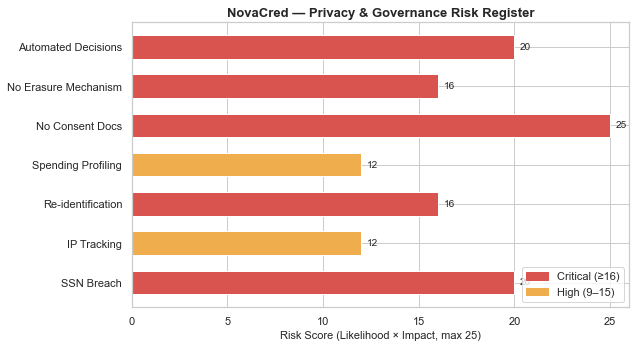

In [8]:
# Visualise likelihood vs impact for key governance risks

risks = [
    ('SSN Breach',              4, 5),
    ('IP Tracking',             3, 4),
    ('Re-identification',       4, 4),
    ('Spending Profiling',      3, 4),
    ('No Consent Docs',         5, 5),
    ('No Erasure Mechanism',    4, 4),
    ('Automated Decisions',     4, 5),
]

labels     = [r[0] for r in risks]
likelihood = [r[1] for r in risks]
impact     = [r[2] for r in risks]
scores     = [l * i for l, i in zip(likelihood, impact)]

colours = ['#d9534f' if s >= 16 else '#f0ad4e' if s >= 9 else '#5bc0de'
           for s in scores]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, scores, color=colours, edgecolor='white', height=0.6)
ax.set_xlabel('Risk Score (Likelihood × Impact, max 25)', fontsize=11)
ax.set_title('NovaCred — Privacy & Governance Risk Register', fontsize=13, fontweight='bold')
ax.set_xlim(0, 26)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(score), va='center', fontsize=10)

red_patch    = mpatches.Patch(color='#d9534f', label='Critical (≥16)')
orange_patch = mpatches.Patch(color='#f0ad4e', label='High (9–15)')
ax.legend(handles=[red_patch, orange_patch], loc='lower right')

plt.tight_layout()
plt.show()

The heatmap identifies **4 Critical risks (score ≥ 16)** and **3 High risks (score 9–15)** 
across NovaCred's current data processing setup.

The three most urgent risks are:

- **No Consent Documentation (25/25)** — the maximum possible score. Every single record 
  in the dataset was processed without any evidence of a lawful basis, making this the 
  most immediate legal exposure NovaCred faces
- **Automated Decisions (20/25)** — fully automated credit rejections with no human 
  oversight mechanism, triggering obligations under both GDPR Art. 22 and the EU AI Act
- **SSN Breach / Re-identification / No Erasure Mechanism (16/25)** — three risks tied 
  at critical level, all stemming from the same root cause: sensitive identifiers stored 
  in plaintext with no deletion or pseudonymization pipeline in place